In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from utils import get_test_images#, overlay_zoom_patch, plot_zoom, color_sr, rgb_to_ycbcr, plot_zoom_patches
from metrics import calculate_psnr
# from models import Upsampler, get_y_tensors Y OTROS MODELOSSSSSSSSSS

In [2]:
#SACAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAar
import torch
import torchvision.transforms as T
from PIL import Image
import torchvision.transforms.functional as F
import numpy as np

def color_sr(sr, color_channels, f):
    """
    Upsample the color channels by f
    Crop the borders to match the SR image size
    Combine the Y channel with the upsampled color channels
    Convert back to RGB and return as numpy array.
    """
    # Upsample Cb, Cr
    upsampled = [F.interpolate(channel, scale_factor=f, mode='bicubic', align_corners=False) for channel in color_channels]
    # Crop borders
    cropped = [channel[:, :, f:-f, f:-f] for channel in upsampled]
    # Convert tensors to PIL images
    to_pil = T.ToPILImage()
    y_pil = to_pil(sr.unsqueeze(0))  # (H, W) -> PIL
    cb_pil = to_pil(cropped[0].squeeze(0))
    cr_pil = to_pil(cropped[1].squeeze(0))
    # Recombinar como YCbCr
    ycbcr = Image.merge("YCbCr", (y_pil, cb_pil, cr_pil))
    # Convertir a RGB
    rgb = ycbcr.convert("RGB")
    return np.array(rgb)

def rgb_to_ycbcr(img):
    """ Convert a PIL RGB image to YCbCr and return all channels as tensors. """
    to_tensor = T.ToTensor()
    ycbcr = img.convert("YCbCr").split()  # Extrae sólo el canal Y como PIL.Image
    tensors = [to_tensor(channel).unsqueeze(0) for channel in ycbcr]  # (1, H, W) for each channel
    return tensors


def get_y_tensors(rgb_imgs):
    """
    Convert a list of RGB images to Y channel tensors.
    
    Args:
        rgb_imgs (list of PIL.Image): List of RGB images.
    
    Returns:
        list of torch.Tensor: List of Y channel tensors of shape (1, H, W)
    """
    to_tensor = T.ToTensor()
    y_tensors = []
    for img in rgb_imgs:
        y = img.convert("YCbCr").split()[0]  # Extrae sólo el canal Y como PIL.Image
        y_tensor = to_tensor(y).unsqueeze(0)  # (1, H, W)
        y_tensors.append(y_tensor)
    return y_tensors

In [3]:
#PONER EN MODELS POR la funcion upsample_images

import torch
import torch.nn as nn
import torch.nn.functional as F

class Upsampler(nn.Module):
    def __init__(self, scale_factor: float, mode: str = "bicubic"):
        super().__init__()
        valid_modes = {"nearest", "bilinear", "bicubic"}
        if mode not in valid_modes:
            raise ValueError(f"Modo '{mode}' no soportado. Elige de {valid_modes}")
        self.scale_factor = scale_factor
        self.mode = mode

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # align_corners solo válido en algunos modos
        align = False if self.mode in {"linear","bilinear","bicubic"} else None
        return F.interpolate(
            x,
            scale_factor=self.scale_factor,
            mode=self.mode,
            align_corners=align
        )

In [ ]:
#poner en utils!
import cv2
import numpy as np
import matplotlib.pyplot as plt
def overlay_zoom_patch(img, zoom=2, patch_ratio=0.25, margin_ratio=0.05, thickness=2):
    img = np.array(img)

    h_img, w_img = img.shape[:2]
    patch_size = int(min(h_img, w_img) * patch_ratio)
    patch_size = max(1, patch_size // 2 * 2)

    margin_x = int(w_img * margin_ratio)
    margin_y = int(h_img * margin_ratio)
    top  = margin_y
    left = w_img - patch_size - margin_x

    img_patch = img[top:top + patch_size, left:left + patch_size]
    
    zoomed_patch = np.repeat(np.repeat(img_patch, zoom, axis=0),zoom, axis=1)

    overlay = img.copy()
    cv2.rectangle(overlay, (left, top), (left + patch_size, top + patch_size), (255, 0, 0), thickness=thickness)

    h_lr, w_lr = img.shape[:2]
    h_zp, w_zp = zoomed_patch.shape[:2]
    dst_x = w_lr - w_zp
    dst_y = h_lr - h_zp

    overlay[dst_y:dst_y + h_zp, dst_x:dst_x + w_zp] = zoomed_patch

    cv2.rectangle(overlay, (dst_x, dst_y), (dst_x + w_zp, dst_y + h_zp), (255, 0, 0), thickness=thickness)

    return overlay

def plot_zoom_patches(set_dict, img_index, factor, models, models_names, zoom_patches_args):
    lr, hr = set_dict['lr'][img_index], set_dict['hr'][img_index]
    lr_patch = overlay_zoom_patch(lr, **zoom_patches_args)
    hr_patch = overlay_zoom_patch(hr, **zoom_patches_args)

    hr_y = get_y_tensors([hr])[0]  # (1, 1, H, W)
    hr_y_crop = hr_y[:, :, factor:-factor, factor:-factor].squeeze(0)  # (1, H', W')

    lr_channels = rgb_to_ycbcr(lr)
    lr_y_channel = lr_channels[0]

    lr_channels = lr_channels[1:]
    # patches= [lr_patch]
    patches= []
    
    # psnr_list = ['LR']
    psnr_list = []
    for model in (models):
        model.eval()
        sr_y = model(lr_y_channel)
        sr_y = torch.clamp(sr_y.cpu(), 0, 1)
        sr_y = sr_y[:, :, factor:-factor, factor:-factor].squeeze(0)
 
        psnr = round(calculate_psnr(hr_y_crop, sr_y, data_range=1.0), 2)
        psnr_list.append(str(psnr) + ' dB')
        sr_color = color_sr(sr_y.squeeze(), lr_channels, factor)
        sr_patch = overlay_zoom_patch(sr_color, **zoom_patches_args)
        patches.append(sr_patch)

    patches.append(hr_patch)
    psnr_list.append('PSNR')
    # sub_titles = ['Low Resolution'] + models_names + ['High Resolution']
    subtitles =  models_names + ['High Resolution']
    subtitles = [name + ' / ' + psnr for name, psnr in zip(subtitles, psnr_list)]
    fig, axes = plt.subplots(1, len(patches), figsize=(12, 6))
    for ax, patch, subtitle in zip(axes, patches, subtitles):
        ax.imshow(patch)
        # ax[i].set_title(sub_titles[i] + ' / ' + psnr_list[i])
        ax.text(
                0.5,                 # en el centro horizontal
                -0.01,               # un poco por debajo del eje
                subtitle,            # texto del subtítulo
                transform=ax.transAxes,
                ha='center',         # alineación horizontal centrada
                va='top',            # alineación vertical arriba
                fontsize='large'     # opcional: tamaño de letra más pequeño
            )
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [5]:
all_images = get_test_images()
print(all_images.keys())
print(all_images[5].keys())
print(all_images[5][2].keys())
print(len(all_images[5][2]['lr']), len(all_images[5][2]['hr']))

dict_keys([5, 14])
dict_keys([2, 3, 4])
dict_keys(['lr', 'hr'])
5 5


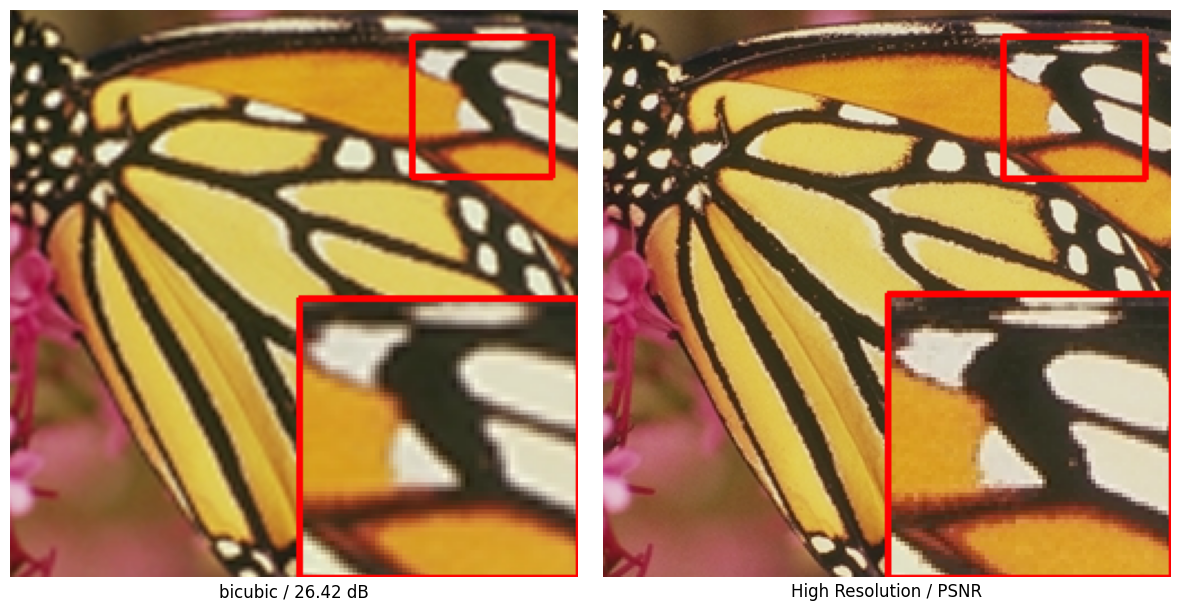

In [29]:
zoom_patches_args = {
    'zoom': 2,
    'patch_ratio': 0.25,
    'margin_ratio': 0.05,
    'thickness': 2
}
set_dict = all_images[5][2]
img_index = 2
factor = 2
models = [
    # Upsampler(scale_factor=factor, mode='nearest'),
    # Upsampler(scale_factor=factor, mode='bilinear'),
    Upsampler(scale_factor=factor, mode='bicubic')
]
# models_names = ["nearest", "bilinear", "bicubic"]
models_names = [ "bicubic"]
plot_zoom_patches(set_dict, img_index, factor, models, models_names, zoom_patches_args)